# Coding Word2Vec from Scratch

In this notebook, I'm going to follow along with [this YouTube video](https://www.youtube.com/watch?v=d2E-pU4H2gc) and build a Word2Vec implementation from scratch.

## Imports

In [1]:
import numpy as np
import pandas as pd
import string
from tqdm import tqdm
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt


## Logging

In [2]:
#####################
# Configure logging #
#####################
import logging
logger = logging.getLogger(__name__)
FORMAT = "[%(filename)s:%(lineno)s - %(name)s::%(funcName)s() ] %(message)s"
logging.basicConfig(format=FORMAT, level=logging.INFO)
# logging.basicConfig(level=logging.INFO)
# Configure this logger to use DEBUG level
logger.setLevel(logging.INFO)

## Load Stopwords

In [3]:
try:
    import nltk
    nltk.download('stopwords')
    logger.info("Downloaded stopwords from nltk...")
except ImportError:
    logger.error("nltk not available. Couldn't download the stopword list.")

try:
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    logger.info("Loaded stopwords from nltk...")
except ImportError:
    logger.error("nltk.corpus.stopwords not available. Using a fallback list.")
    stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"])
    logger.info("Using fallback stopwords list...")


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/javidjamae/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[2468238545.py:4 - __main__::<module>() ] Downloaded stopwords from nltk...
[2468238545.py:11 - __main__::<module>() ] Loaded stopwords from nltk...


## Setup Input Text

In [4]:
original_text = "Today we will \" \n\n be 0 99 learning about the fundamentals of data science and statistics. Data Science and statistics are hot and growing fields with alternative names of machine learning, artificial intelligence, big data, etc. I'm really excited to talk to you about data science and statistics because data science and statistics have long been a passions of mine. I didn't used to be very good at data science and statistics but after studying data science and statistics for a long time, I got better and better at it until I became a data science and statistics expert. I'm really excited to talk to you about data science and statistics, thanks for listening to me talk about data science and statistics."
print(original_text)

Today we will " 

 be 0 99 learning about the fundamentals of data science and statistics. Data Science and statistics are hot and growing fields with alternative names of machine learning, artificial intelligence, big data, etc. I'm really excited to talk to you about data science and statistics because data science and statistics have long been a passions of mine. I didn't used to be very good at data science and statistics but after studying data science and statistics for a long time, I got better and better at it until I became a data science and statistics expert. I'm really excited to talk to you about data science and statistics, thanks for listening to me talk about data science and statistics.


In [5]:
text = original_text.replace('\n', '')
text = text.translate(str.maketrans('', '', string.punctuation))
text = ''.join([t for t in text if t not in list('0123456789')])
text = text.replace('”', '').replace('“', '').replace('’', '').lower().split()
text = [w for w in text if w not in stop_words][:2000]
print(text)

print("Vocab Size:", len(set(text)))

['today', 'learning', 'fundamentals', 'data', 'science', 'statistics', 'data', 'science', 'statistics', 'hot', 'growing', 'fields', 'alternative', 'names', 'machine', 'learning', 'artificial', 'intelligence', 'big', 'data', 'etc', 'im', 'really', 'excited', 'talk', 'data', 'science', 'statistics', 'data', 'science', 'statistics', 'long', 'passions', 'mine', 'didnt', 'used', 'good', 'data', 'science', 'statistics', 'studying', 'data', 'science', 'statistics', 'long', 'time', 'got', 'better', 'better', 'became', 'data', 'science', 'statistics', 'expert', 'im', 'really', 'excited', 'talk', 'data', 'science', 'statistics', 'thanks', 'listening', 'talk', 'data', 'science', 'statistics']
Vocab Size: 34


## Prepare Training Data

In [6]:
WINDOW_SIZE = 3
NUM_NEGATIVE_SAMPLES = 3

data = []

print("Enum over: ", text[WINDOW_SIZE-1:-WINDOW_SIZE])

#iterate over all words
for idx,center_word in enumerate(text[WINDOW_SIZE-1:-WINDOW_SIZE]):
    
    #iterate over the context words around the center word
    context_words = [context_word for context_word in text[idx:idx+2*WINDOW_SIZE-1] if context_word != center_word]
    #print(f"Index: {idx}, Center Word: {center_word}, Context Words: {context_words}")
    
    for context_word in context_words:    
        data.append([center_word, context_word, 1])
        #print(f"Appending: {[center_word, context_word, 1]}")
        
        #get words NOT in the current context as negative examples
        negative_samples = np.random.choice([w for w in text[WINDOW_SIZE-1:-WINDOW_SIZE] if w != center_word and w not in context_words], NUM_NEGATIVE_SAMPLES)
        
        for negative_samp in negative_samples:

            #add a training row
            data.append([center_word, negative_samp, 0])
            #print(f"Appending: {[center_word, negative_samp, 0]}")



Enum over:  ['fundamentals', 'data', 'science', 'statistics', 'data', 'science', 'statistics', 'hot', 'growing', 'fields', 'alternative', 'names', 'machine', 'learning', 'artificial', 'intelligence', 'big', 'data', 'etc', 'im', 'really', 'excited', 'talk', 'data', 'science', 'statistics', 'data', 'science', 'statistics', 'long', 'passions', 'mine', 'didnt', 'used', 'good', 'data', 'science', 'statistics', 'studying', 'data', 'science', 'statistics', 'long', 'time', 'got', 'better', 'better', 'became', 'data', 'science', 'statistics', 'expert', 'im', 'really', 'excited', 'talk', 'data', 'science', 'statistics', 'thanks', 'listening', 'talk']


In [7]:
print(len(data))

984


In [8]:
print(data[0:5])

[['fundamentals', 'today', 1], ['fundamentals', 'expert', 0], ['fundamentals', 'talk', 0], ['fundamentals', 'fields', 0], ['fundamentals', 'learning', 1]]


In [9]:
df = pd.DataFrame(columns=['center_word', 'context_word', 'label'], data=data)
words = np.intersect1d(df.context_word, df.center_word)
df = df[(df.center_word.isin(words)) & (df.context_word.isin(words))].reset_index(drop=True)

In [10]:
df

,center_word,context_word,label
0,fundamentals,expert,0
1,fundamentals,talk,0
2,fundamentals,fields,0
3,fundamentals,learning,1
4,fundamentals,excited,0
...,...,...,...
978,talk,excited,0
979,talk,science,1
980,talk,statistics,0
981,talk,statistics,0


In [11]:
# Looks like there may be a little bug since the word today is not appearing in the words list
# Probably has to do with the way he's enumerating when preparing the training data above
print("Words count:", len(words))
print("Words count:", len(set(text)))
print("Difference between text and words:", set(text).difference(set(words)))

Words count: 33
Words count: 34
Difference between text and words: {'today'}


## Functions

In [12]:
def sigmoid(v, scale=1):
    return 1 / (1 + np.exp(-scale*v))

In [13]:
def update_embeddings(df, main_embeddings, context_embeddings, learning_rate, debug=False):
    
    #get differences between main embeddings and corresponding context embeddings
    main_embeddings_center = main_embeddings.loc[df.center_word].values
    # print("main_embeddings.shape: ", main_embeddings.shape ) # (33,5)
    # print("len(df.center_word): ", len(df.center_word) ) # 983
    # print("df.center_word.shape: ", df.center_word.shape ) # (983,)
    # print("len(main_embeddings_center): ", len(main_embeddings_center) ) # (983,)
    # print("main_embeddings_center.shape: ", main_embeddings_center.shape ) # (983, 5)
    # print("len(main_embeddings.loc[df.center_word]): ", len(main_embeddings.loc[df.center_word])) # (983,)

    # print("df.center_word: ", df.center_word )
    # print("main_embeddings_center: ", main_embeddings_center)
    # print("main_embeddings.loc[df.center_word]: ", main_embeddings.loc[df.center_word])

    context_embeddings_context = context_embeddings.loc[df.context_word].values
    diffs = context_embeddings_context - main_embeddings_center
    
    #get similarities, scores, and errors between main embeddings and corresponding context embeddings
    dot_prods = np.sum(main_embeddings_center * context_embeddings_context, axis=1)
    scores = sigmoid(dot_prods)
    errors = (df.label - scores).values.reshape(-1,1)
    
    #calculate updates
    updates = diffs*errors*learning_rate
    updates_df = pd.DataFrame(data=updates)
    updates_df['center_word'] = df.center_word
    updates_df['context_word'] = df.context_word
    updates_df_center = updates_df.groupby('center_word').sum()
    updates_df_context = updates_df.groupby('context_word').sum()
    
    if debug:
        plot_words(debug)
    
    #apply updates
    main_embeddings += updates_df_center.loc[main_embeddings.index]
    context_embeddings -= updates_df_context.loc[context_embeddings.index]
    
    #normalize embeddings
    main_embeddings = normalize_data(main_embeddings)
    context_embeddings = normalize_data(context_embeddings)
    
    #return the updated embeddings
    return main_embeddings, context_embeddings

In [14]:
def normalize_data(data):
    row_norms = np.sqrt((data.values**2).sum(axis=1)).reshape(-1,1)
    return data.divide(row_norms, axis='index')

In [24]:
def plot_words(debug):
    plt.figure(figsize=(8,4))
    
    plt.subplot(1,2,1)
    lim_main_first = main_embeddings.loc[[debug[0]]]
    lim_main_second = main_embeddings.loc[[debug[1]]]
    p1 = plt.scatter(lim_main_first[0], lim_main_first[1], color='r')
    #plt.arrow(0, 0, float(lim_main_first[0]),         float(lim_main_first[1]),         head_width=0.01, length_includes_head=True)
    plt.arrow(0, 0, float(lim_main_first.iloc[0, 0]), float(lim_main_first.iloc[0, 1]), head_width=0.01, length_includes_head=True)

    for idx,row in lim_main_first.iterrows():
        plt.text(row[0], row[1], str(idx))
    p2 = plt.scatter(lim_main_second[0], lim_main_second[1], color='r')
    #plt.arrow(0,0,float(lim_main_second[0]), float(lim_main_second[1]), head_width=0.01, length_includes_head=True)
    plt.arrow(0,0,float(lim_main_second.iloc[0,0]), float(lim_main_second.iloc[0,1]), head_width=0.01, length_includes_head=True)
    
    for idx,row in lim_main_second.iterrows():
        plt.text(row[0], row[1], str(idx))
    sim = 1 - cosine(main_embeddings.loc[debug[0]], main_embeddings.loc[debug[1]])
    plt.title('Sim = %s'%round(sim,4), fontsize=20)
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.axhline(0, color='k', linestyle='--', alpha=0.5)
    
    t = np.arange(0, 3.14*2+0.1, 0.1)
    plt.plot(np.cos(t), np.sin(t), linewidth=1, color='k', alpha=0.5, linestyle='--')
    
    ###################################
    
    plt.subplot(1,2,2)
    lim_main = main_embeddings.loc[[debug[0]]]
    lim_context = context_embeddings.loc[[debug[1]]]
    p1 = plt.scatter(lim_main[0], lim_main[1], color='r')
    #plt.arrow(0,0,float(lim_main[0]), float(lim_main[1]), head_width=0.01, length_includes_head=True)
    plt.arrow(0,0,float(lim_main.iloc[0,0]), float(lim_main.iloc[0,1]), head_width=0.01, length_includes_head=True)
    for idx,row in lim_main.iterrows():
        plt.text(row[0], row[1], str(idx))
    p2 = plt.scatter(lim_context[0], lim_context[1], color='b')
    #plt.arrow(0,0,float(lim_context[0]), float(lim_context[1]), head_width=0.01, length_includes_head=True)
    plt.arrow(0,0,float(lim_context.iloc[0,0]), float(lim_context.iloc[0,1]), head_width=0.01, length_includes_head=True)
    for idx,row in lim_context.iterrows():
        plt.text(row[0], row[1], str(idx))
    sim = 1 - cosine(main_embeddings.loc[debug[0]], context_embeddings.loc[debug[1]])
    plt.title('Sim = %s'%round(sim,4), fontsize=20)
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.axhline(0, color='k', linestyle='--', alpha=0.5)
    
    plt.plot(np.cos(t), np.sin(t), linewidth=1, color='k', alpha=0.5, linestyle='--')
    
    plt.show()

## Run Word2Vec

-----


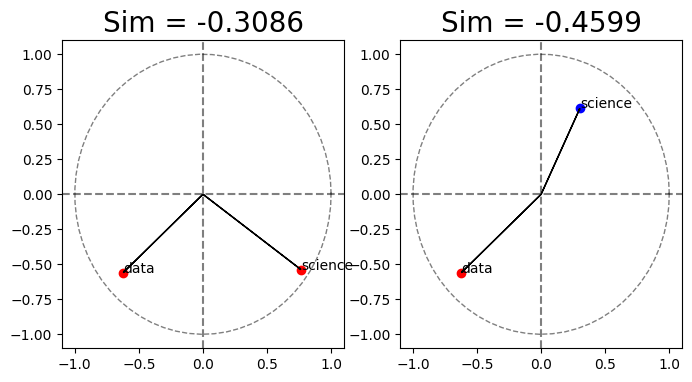

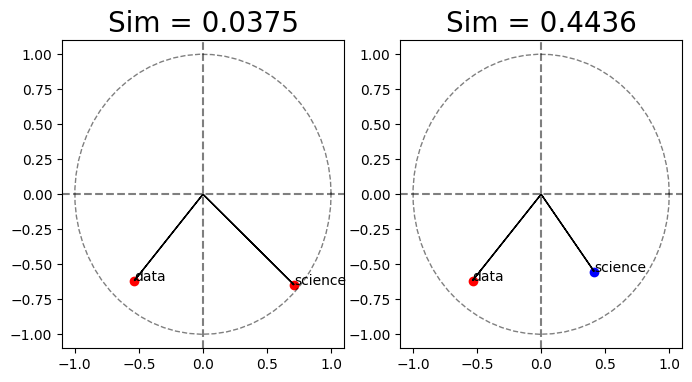

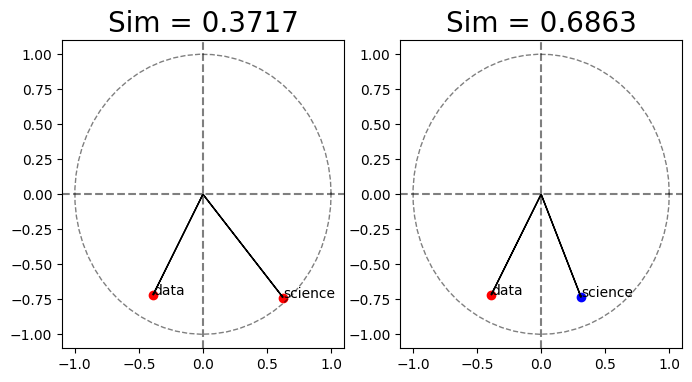

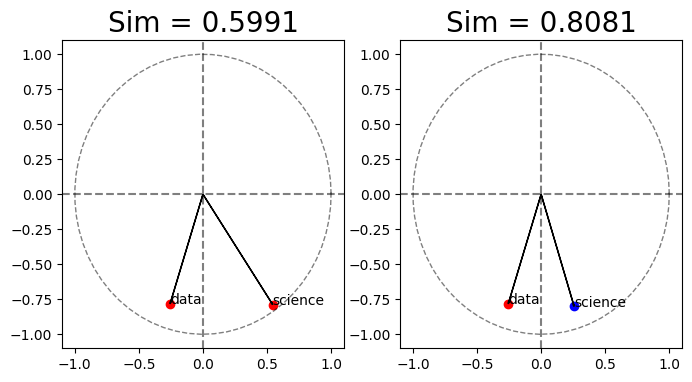

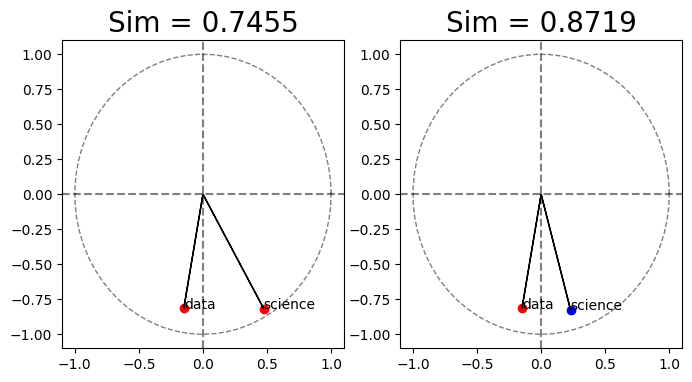

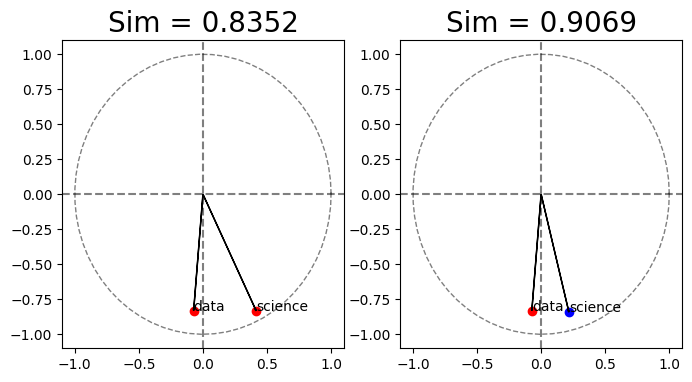

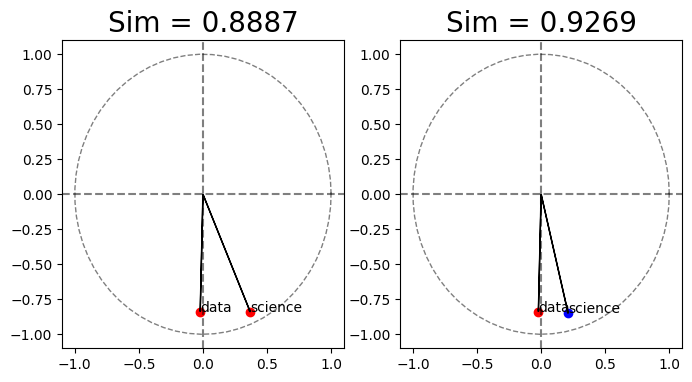

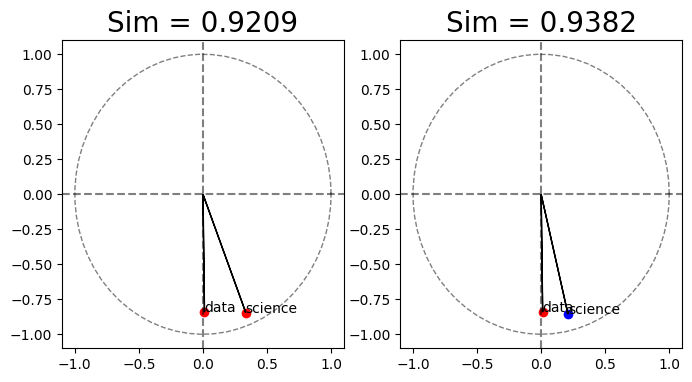

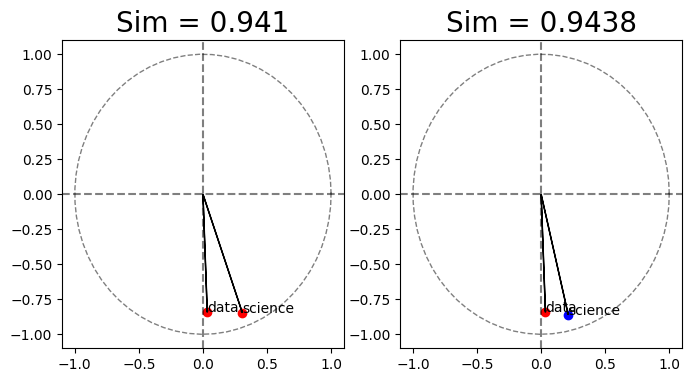

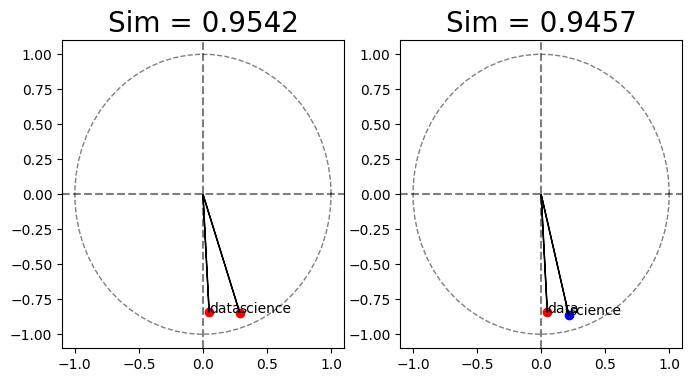

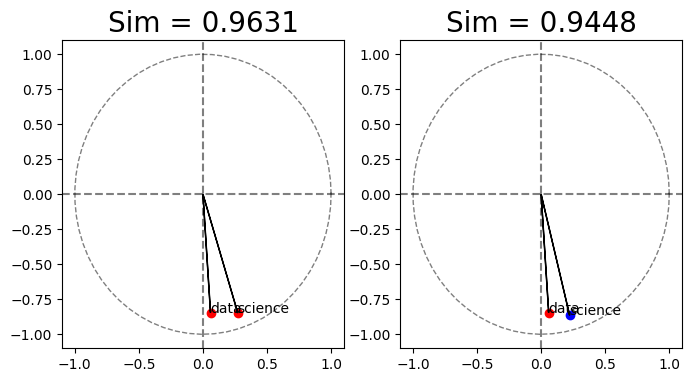

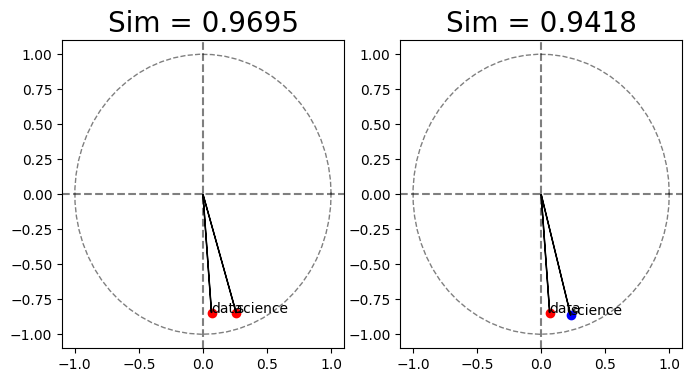

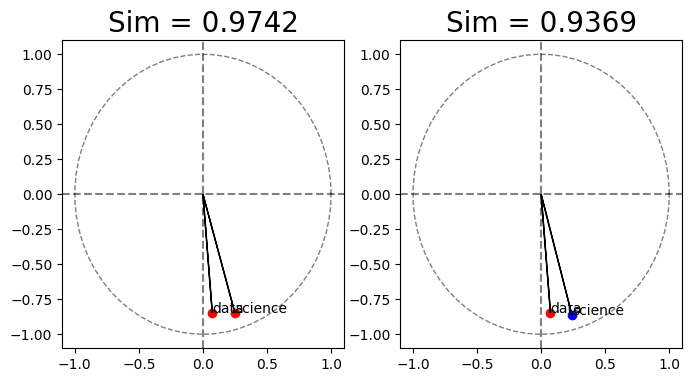

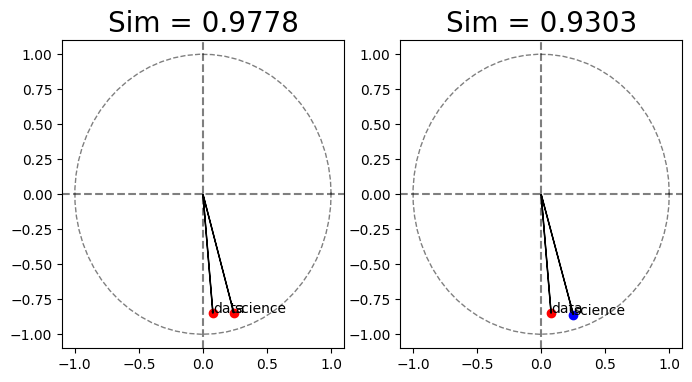

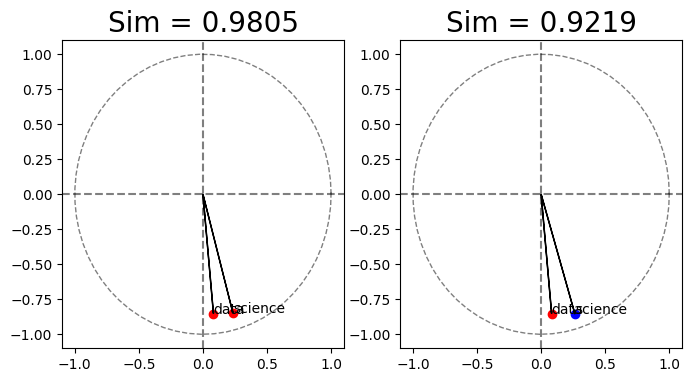

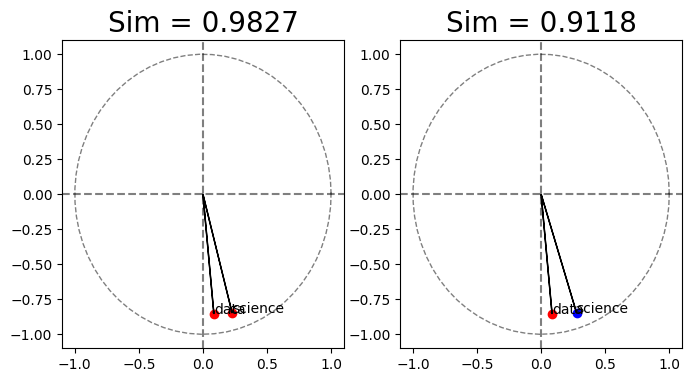

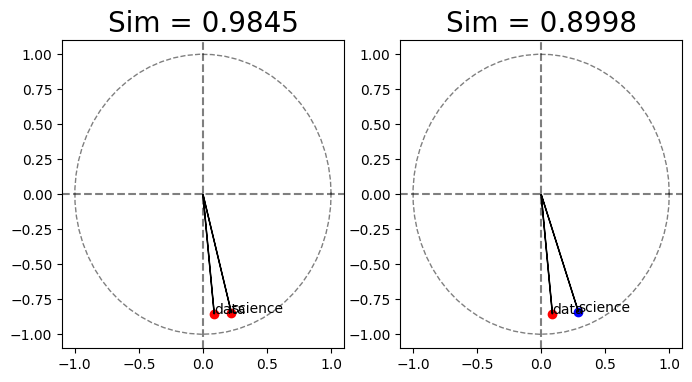

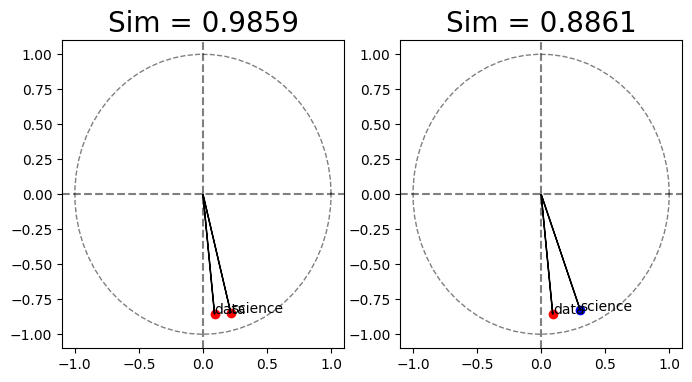

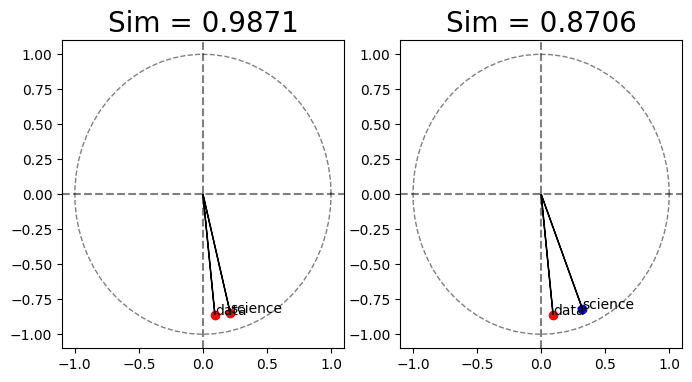

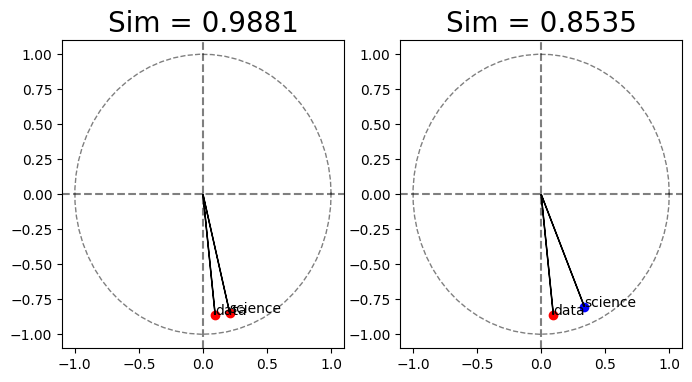

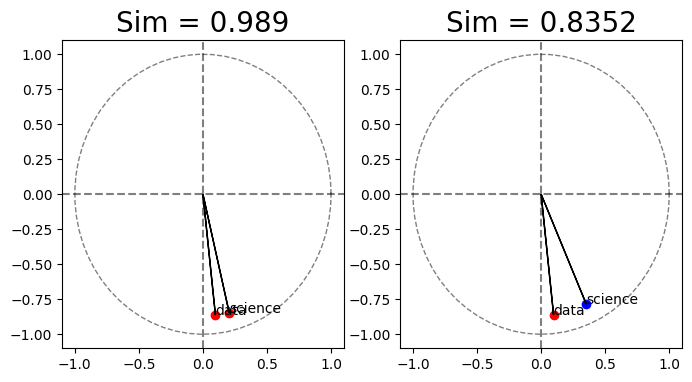

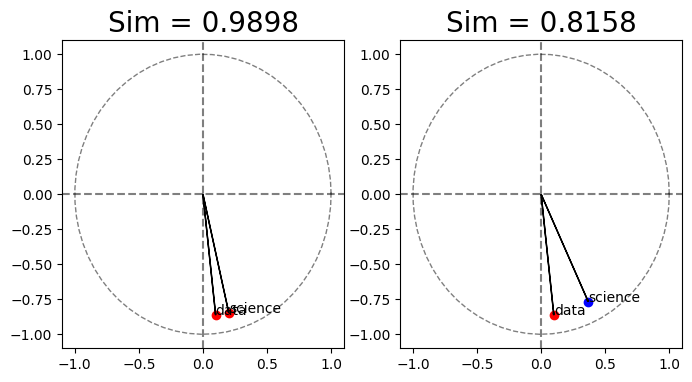

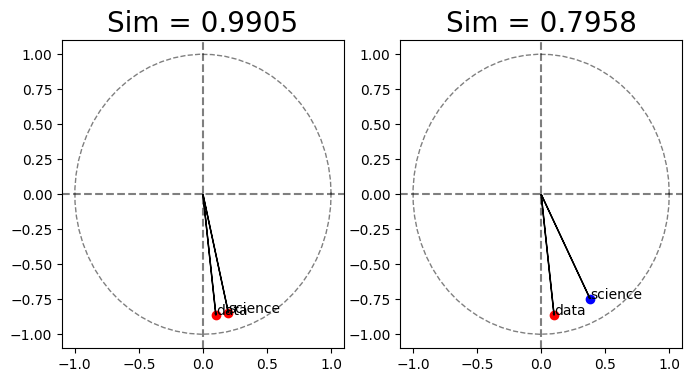

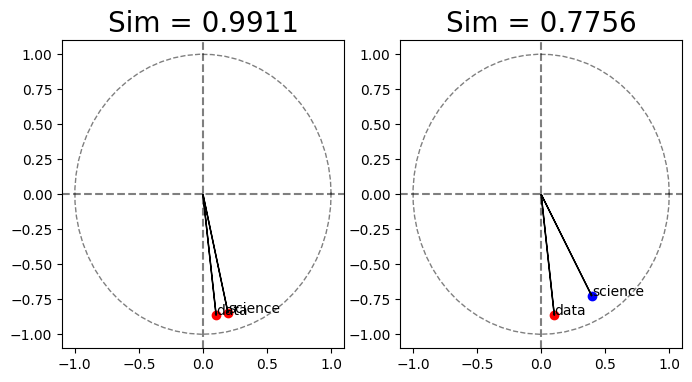

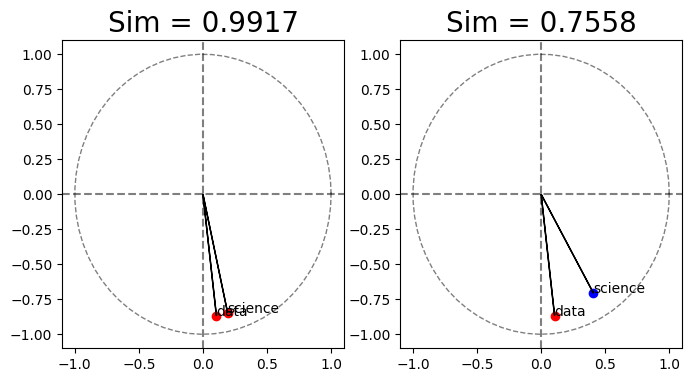

In [25]:
EMBEDDING_SIZE = 5

# print("main_embeddings shape: ", (len(words), EMBEDDING_SIZE))
# Create a (33, 5) array, randomized normally around 0
main_embeddings = np.random.normal(0,0.1,(len(words), EMBEDDING_SIZE))
# print("main_embeddings[0]", main_embeddings[0])
row_norms = np.sqrt((main_embeddings**2).sum(axis=1)).reshape(-1,1)
# print("row_norms shape:", row_norms.shape)
main_embeddings = main_embeddings / row_norms
# print("normalized main_embeddings[0]", main_embeddings[0])

# Why do we need to normalize if it's already a randomly selected from a normal distribution??

context_embeddings = np.random.normal(0,0.1,(len(words), EMBEDDING_SIZE))
row_norms = np.sqrt((context_embeddings**2).sum(axis=1)).reshape(-1,1)
context_embeddings = context_embeddings / row_norms

main_embeddings = pd.DataFrame(data=main_embeddings, index=words)
context_embeddings = pd.DataFrame(data=context_embeddings, index=words)

print("-----")
# for _ in range(1):
for _ in range(25):
    main_embeddings, context_embeddings = update_embeddings(df, main_embeddings, context_embeddings, 0.1, ['data', 'science'])
    # main_embeddings, context_embeddings = update_embeddings(df, main_embeddings, context_embeddings, 0.1)


In [17]:
L = []
for w1 in words:
    for w2 in words:
        if w1 != w2:
            sim = 1 - cosine(main_embeddings.loc[w1], main_embeddings.loc[w2])
            L.append((w1,w2,sim))
sorted([item for item in L if item[0] == 'data'], key=lambda t: -t[2])[:10]

[('data', 'studying', 0.9953969286536244),
 ('data', 'science', 0.9801872213756516),
 ('data', 'statistics', 0.9775031524825901),
 ('data', 'hot', 0.9666855856441321),
 ('data', 'expert', 0.878668153820936),
 ('data', 'became', 0.8219301710920781),
 ('data', 'thanks', 0.8106026618684815),
 ('data', 'good', 0.779218333604845),
 ('data', 'fundamentals', 0.6521887504492498),
 ('data', 'growing', 0.6484306425658254)]

## Visualize all the embeddings


In [18]:
#!pip3 install scikit-learn

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=2)
transf_embeddings = pca.fit_transform(main_embeddings.values)
words_used = main_embeddings.index

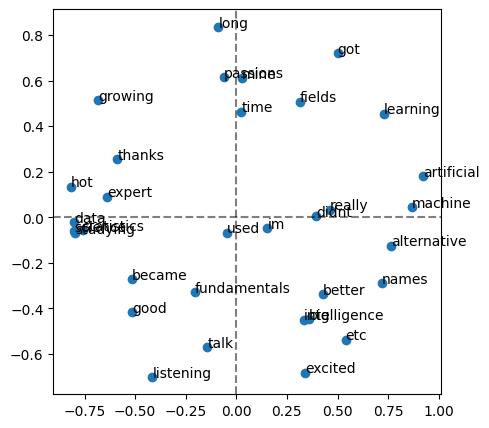

In [21]:
plt.figure(figsize=(5,5))
plt.scatter(transf_embeddings[:,0], transf_embeddings[:,1])
for idx,row in enumerate(transf_embeddings):
    plt.text(row[0], row[1], str(words_used[idx]))
plt.axvline(0, color='k', linestyle='--', alpha=0.5)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)

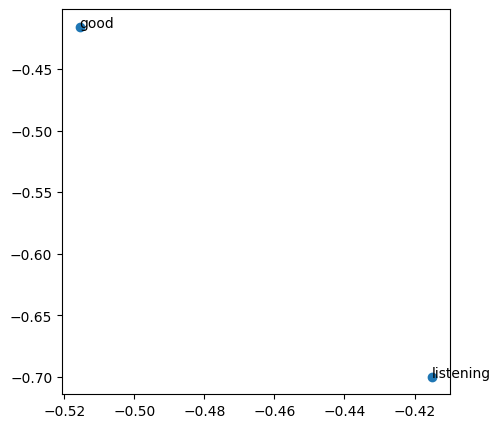

In [22]:
plt.figure(figsize=(5,5))

chosen_idxs = (transf_embeddings[:,0] < -.25) & (transf_embeddings[:,1] < -0.4)
transf_embeddings = transf_embeddings[chosen_idxs]
words_used = words_used[chosen_idxs]

plt.scatter(transf_embeddings[:,0], transf_embeddings[:,1])
for idx,row in enumerate(transf_embeddings):
    plt.text(row[0], row[1], str(words_used[idx]))
